# EXAMEN 1 BIMESTRE
**NOMBRE: BRYAN YUNGA**

**Instalar las dependencias**

In [23]:
!pip install -q --disable-pip-version-check sentence-transformers==3.0.1 scikit-learn==1.5.1 pandas==2.2.2 numpy==1.26.4 matplotlib==3.9.1 seaborn==0.13.2 nltk==3.8.1 tqdm==4.66.4 tabulate==0.9.0
print("✅ Todas las dependencias instaladas correctamente.")

✅ Todas las dependencias instaladas correctamente.


**IMPORTACIONES**

Este bloque importa las librerías necesarias para el proyecto (como pandas, numpy, sentence-transformers, scikit-learn y matplotlib) y establece la configuración global, como la definición de semillas de aleatoriedad (RANDOM_SEED) para garantizar la reproducibilidad de los experimentos y gráficos.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import warnings
warnings.filterwarnings("ignore")

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from tqdm import tqdm
from IPython.display import display, HTML
from tabulate import tabulate

# Descargar recursos de NLTK
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Semilla para reproducibilidad
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Configuración de visualización
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 20)
plt.rcParams["figure.figsize"] = (12, 6)

print("✅ Librerías cargadas correctamente.")
print(f"   pandas     : {pd.__version__}")
print(f"   numpy      : {np.__version__}")
print(f"   matplotlib : {plt.matplotlib.__version__}")

✅ Librerías cargadas correctamente.
   pandas     : 2.3.3
   numpy      : 2.4.6
   matplotlib : 3.10.0


**Carga del Corpus**

Este bloque automatiza la descarga y carga inicial del corpus directamente desde la API de Kaggle, obteniendo los archivos de películas y reseñas críticas para iniciar el análisis en el notebook sin necesidad de subirlos manualmente.

In [6]:
# --- Cargar ambos archivos ---
df_movies  = pd.read_csv("/kaggle/input/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset/rotten_tomatoes_movies.csv")
df_reviews = pd.read_csv("/kaggle/input/datasets/stefanoleone992/rotten-tomatoes-movies-and-critic-reviews-dataset/rotten_tomatoes_critic_reviews.csv")

print("=" * 60)
print("📽️  MOVIES — shape:", df_movies.shape)
print("=" * 60)
display(df_movies.head(3))

print("\n" + "=" * 60)
print("📝  REVIEWS — shape:", df_reviews.shape)
print("=" * 60)
display(df_reviews.head(3))

print("\n📋 Columnas en MOVIES :", list(df_movies.columns))
print("📋 Columnas en REVIEWS:", list(df_reviews.columns))

📽️  MOVIES — shape: (17712, 22)


,rotten_tomatoes_link,movie_title,movie_info,critics_consensus,content_rating,genres,directors,authors,actors,original_release_date,...,production_company,tomatometer_status,tomatometer_rating,tomatometer_count,audience_status,audience_rating,audience_count,tomatometer_top_critics_count,tomatometer_fresh_critics_count,tomatometer_rotten_critics_count
0,m/0814255,Percy Jackson & the Olympians: The Lightning Thief,"Always trouble-prone, the life of teenager Percy Jackson (Logan Lerman) gets...","Though it may seem like just another Harry Potter knockoff, Percy Jackson be...",PG,"Action & Adventure, Comedy, Drama, Science Fiction & Fantasy",Chris Columbus,"Craig Titley, Chris Columbus, Rick Riordan","Logan Lerman, Brandon T. Jackson, Alexandra Daddario, Jake Abel, Sean Bean, ...",2010-02-12,...,20th Century Fox,Rotten,49.0,149.0,Spilled,53.0,254421.0,43,73,76
1,m/0878835,Please Give,Kate (Catherine Keener) and her husband Alex (Oliver Platt) are wealthy New ...,"Nicole Holofcener's newest might seem slight in places, but its rendering of...",R,Comedy,Nicole Holofcener,Nicole Holofcener,"Catherine Keener, Amanda Peet, Oliver Platt, Rebecca Hall, Sarah Steele, Ann...",2010-04-30,...,Sony Pictures Classics,Certified-Fresh,87.0,142.0,Upright,64.0,11574.0,44,123,19
2,m/10,10,"A successful, middle-aged Hollywood songwriter falls hopelessly in love with...","Blake Edwards' bawdy comedy may not score a perfect 10, but Dudley Moore's s...",R,"Comedy, Romance",Blake Edwards,Blake Edwards,"Dudley Moore, Bo Derek, Julie Andrews, Robert Webber, Dee Wallace, Sam Jones...",1979-10-05,...,Waner Bros.,Fresh,67.0,24.0,Spilled,53.0,14684.0,2,16,8



📝  REVIEWS — shape: (1130017, 8)


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology to contemporary American plac...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiffure of writhing snakes and sto..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,"With a top-notch cast and dazzling special effects, this will tide the teens..."



📋 Columnas en MOVIES : ['rotten_tomatoes_link', 'movie_title', 'movie_info', 'critics_consensus', 'content_rating', 'genres', 'directors', 'authors', 'actors', 'original_release_date', 'streaming_release_date', 'runtime', 'production_company', 'tomatometer_status', 'tomatometer_rating', 'tomatometer_count', 'audience_status', 'audience_rating', 'audience_count', 'tomatometer_top_critics_count', 'tomatometer_fresh_critics_count', 'tomatometer_rotten_critics_count']
📋 Columnas en REVIEWS: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


**Selección de campos y construcción del corpus de documentos**

Este bloque construye el corpus de texto uniendo la tabla de reseñas con la de películas para obtener títulos limpios. Define cada documento como una reseña individual combinando el movie_title (ancla semántica) con el review_content (texto descriptivo), mientras preserva el review_score como metadato y el rotten_tomatoes_link como identificador único.

In [7]:
# Seleccionar columnas relevantes de reviews
cols_reviews = ["rotten_tomatoes_link", "critic_name", "review_content", "review_score"]
df = df_reviews[cols_reviews].copy()

# Traer el título de la película desde df_movies
df_title = df_movies[["rotten_tomatoes_link", "movie_title"]].drop_duplicates()
df = df.merge(df_title, on="rotten_tomatoes_link", how="left")

# Eliminar filas sin review_content o movie_title
df = df.dropna(subset=["review_content", "movie_title"]).reset_index(drop=True)

# Crear campo combinado: título + reseña
df["text_combined"] = df["movie_title"].str.strip() + ". " + df["review_content"].str.strip()

# ID único por fila
df["doc_id"] = df.index

print(f"📊 Total de documentos (reseñas): {len(df):,}")
print(f"📊 Películas únicas             : {df['movie_title'].nunique():,}")
print(f"\n📋 Muestra del corpus:")
display(df[["doc_id", "movie_title", "text_combined"]].head(5))

📊 Total de documentos (reseñas): 1,064,109
📊 Películas únicas             : 17,085

📋 Muestra del corpus:


,doc_id,movie_title,text_combined
0,0,Percy Jackson & the Olympians: The Lightning Thief,Percy Jackson & the Olympians: The Lightning Thief. A fantasy adventure that...
1,1,Percy Jackson & the Olympians: The Lightning Thief,"Percy Jackson & the Olympians: The Lightning Thief. Uma Thurman as Medusa, t..."
2,2,Percy Jackson & the Olympians: The Lightning Thief,Percy Jackson & the Olympians: The Lightning Thief. With a top-notch cast an...
3,3,Percy Jackson & the Olympians: The Lightning Thief,Percy Jackson & the Olympians: The Lightning Thief. Whether audiences will g...
4,4,Percy Jackson & the Olympians: The Lightning Thief,Percy Jackson & the Olympians: The Lightning Thief. What's really lacking in...


**Pipeline de preprocesamiento**

Este bloque implementa un pipeline de preprocesamiento de texto que limpia el corpus mediante la conversión a minúsculas, eliminación de puntuación, espacios redundantes y stopwords, aplicando además lematización para reducir variantes morfológicas. Este tratamiento mantiene las palabras legibles y completas (evitando la estemización) para asegurar que el modelo SentenceTransformer aproveche el contexto semántico óptimo al generar los embeddings.

In [8]:

lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words("english"))

def preprocess_text(text: str) -> str:
    """
    Pipeline completo de preprocesamiento textual.
    Retorna el texto limpio, lematizado y sin stopwords.
    """
    if not isinstance(text, str):
        return ""

    # 1. Minúsculas
    text = text.lower()

    # 2. Eliminar puntuación (conservar espacios)
    text = text.translate(str.maketrans(string.punctuation, " " * len(string.punctuation)))

    # 3. Eliminar caracteres no ASCII (acentos, símbolos raros)
    text = re.sub(r"[^\x00-\x7F]+", " ", text)

    # 4. Eliminar números sueltos (opcionales, poco informativos)
    text = re.sub(r"\b\d+\b", "", text)

    # 5. Eliminar espacios redundantes
    text = re.sub(r"\s+", " ", text).strip()

    # 6. Eliminar stopwords + lematización
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]

    return " ".join(tokens)

# Aplicar preprocesamiento
print("⏳ Aplicando preprocesamiento...")
df["text_preprocessed"] = df["text_combined"].apply(preprocess_text)

# Mostrar comparación antes/después
print("\n✅ Preprocesamiento completado.\n")
print("─" * 80)
print("ORIGINAL  :", df["text_combined"].iloc[0][:200])
print("─" * 80)
print("PROCESADO :", df["text_preprocessed"].iloc[0][:200])
print("─" * 80)

# Estadísticas de longitud
df["text_len"] = df["text_preprocessed"].apply(lambda x: len(x.split()))
print(f"\n📊 Estadísticas de longitud (tokens preprocesados):")
print(df["text_len"].describe().to_string())

⏳ Aplicando preprocesamiento...

✅ Preprocesamiento completado.

────────────────────────────────────────────────────────────────────────────────
ORIGINAL  : Percy Jackson & the Olympians: The Lightning Thief. A fantasy adventure that fuses Greek mythology to contemporary American places and values. Anyone around 15 (give or take a couple of years) will th
────────────────────────────────────────────────────────────────────────────────
PROCESADO : percy jackson olympian lightning thief fantasy adventure fuse greek mythology contemporary american place value anyone around give take couple year thrill visual spectacle
────────────────────────────────────────────────────────────────────────────────

📊 Estadísticas de longitud (tokens preprocesados):
count    1.064109e+06
mean     1.427302e+01
std      5.538136e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.400000e+01
75%      1.800000e+01
max      5.000000e+01


Generación de embeddings (Modelo Principal)

**Función de búsqueda por similitud coseno**

Este bloque de código se encarga de la transformación del corpus de texto en vectores numéricos utilizando la librería SentenceTransformers. Su propósito central es cargar y aplicar el modelo all-MiniLM-L6-v2, una arquitectura optimizada de 384 dimensiones que destaca por su velocidad y eficiencia al capturar la similitud semántica en inglés. Adicionalmente, el script establece un parámetro de control (MAX_DOCS) para limitar la cantidad de documentos a procesar en caso de que el volumen de datos sea excesivo, sugiriendo un piso mínimo de 10,000 documentos para garantizar la representatividad y robustez de los resultados en el marco de la evaluación.

In [12]:
MAX_DOCS   = 10_000          # Ajusta según tu RAM / tiempo disponible
MODEL_NAME = "all-MiniLM-L6-v2"

# Subconjunto reproducible
df_corpus = df.sample(n=min(MAX_DOCS, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)
print(f"📦 Corpus de trabajo: {len(df_corpus):,} documentos")

# Cargar modelo
print(f"\n⏳ Cargando modelo '{MODEL_NAME}'...")
model = SentenceTransformer(MODEL_NAME)
print(f"✅ Modelo cargado. Dimensión de embeddings: {model.get_sentence_embedding_dimension()}")

# Generar embeddings en lotes (batch_size=128 es eficiente)
print("\n⏳ Generando embeddings del corpus (esto puede tomar unos minutos)...")
corpus_texts = df_corpus["text_preprocessed"].tolist()

embeddings = model.encode(
    corpus_texts,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True   # L2-normalización → coseno = producto punto
)

print(f"\n✅ Embeddings generados.")
print(f"   Shape: {embeddings.shape}  →  ({len(df_corpus):,} docs × {embeddings.shape[1]} dims)")

# Guardar en numpy para reutilización
np.save("corpus_embeddings_minilm.npy", embeddings)
print("💾 Embeddings guardados en 'corpus_embeddings_minilm.npy'")

📦 Corpus de trabajo: 10,000 documentos

⏳ Cargando modelo 'all-MiniLM-L6-v2'...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Modelo cargado. Dimensión de embeddings: 384

⏳ Generando embeddings del corpus (esto puede tomar unos minutos)...


Batches:   0%|          | 0/79 [00:00<?, ?it/s]


✅ Embeddings generados.
   Shape: (10000, 384)  →  (10,000 docs × 384 dims)
💾 Embeddings guardados en 'corpus_embeddings_minilm.npy'


**Motor de recuperación por similitud coseno**

In [13]:
def search(
    query: str,
    model: SentenceTransformer,
    corpus_embeddings: np.ndarray,
    df_corpus: pd.DataFrame,
    k: int = 5,
    preprocess: bool = True
) -> pd.DataFrame:
    """
    Recupera los k documentos más relevantes para una consulta.

    Parámetros
    ----------
    query            : Consulta textual en lenguaje natural
    model            : Modelo SentenceTransformer cargado
    corpus_embeddings: Array numpy (n_docs × dim), L2-normalizado
    df_corpus        : DataFrame con columnas doc_id, movie_title, text_preprocessed
    k                : Número de resultados a devolver
    preprocess       : Si True, aplica el mismo pipeline al query

    Retorna
    -------
    DataFrame con columnas: Ranking, doc_id, Título, Fragmento, Similitud
    """
    # 1. Preprocesar query (misma transformación que corpus)
    query_clean = preprocess_text(query) if preprocess else query

    # 2. Generar embedding del query (normalizado)
    query_emb = model.encode(
        [query_clean],
        normalize_embeddings=True,
        convert_to_numpy=True
    )

    # 3. Calcular similitud coseno (producto punto porque están normalizados)
    sims = cosine_similarity(query_emb, corpus_embeddings)[0]

    # 4. Obtener índices top-k (mayor similitud primero)
    top_indices = np.argsort(sims)[::-1][:k]

    # 5. Construir DataFrame de resultados
    results = []
    for rank, idx in enumerate(top_indices, start=1):
        row = df_corpus.iloc[idx]
        fragment = row["text_combined"][:200] + "..." if len(row["text_combined"]) > 200 else row["text_combined"]
        results.append({
            "Ranking"  : rank,
            "doc_id"   : int(row["doc_id"]),
            "Título"   : row["movie_title"],
            "Fragmento": fragment,
            "Similitud": round(float(sims[idx]), 4)
        })

    return pd.DataFrame(results)


# --- Test rápido ---
test_result = search("action movie", model, embeddings, df_corpus, k=3)
print("🔎 Test de búsqueda — 'action movie' (top 3):")
display(test_result)

🔎 Test de búsqueda — 'action movie' (top 3):


,Ranking,doc_id,Título,Fragmento,Similitud
0,1,718682,The Scorpion King,The Scorpion King. The bottom line in this kind of movie is how good are the...,0.5479
1,2,457930,Kill Bill: Volume 2,Kill Bill: Volume 2. A witty and entertaining action movie.,0.5431
2,3,276785,Domino,"Domino. A well-paced action movie, if a little long, with an unusual feeling...",0.5383


**Ejecución de las 8 consultas obligatorias**

In [14]:
TOP_K = 5

QUERIES = {
    "Q1": "science fiction movie with advanced technology",
    "Q2": "romantic story with emotional relationships",
    "Q3": "action movie with intense fight scenes",
    "Q4": "horror film that creates fear and suspense",
    "Q5": "visually impressive movie with weak storyline",
    "Q6": "emotionally moving performance by the lead actor",
    "Q7": "predictable plot but entertaining experience",
    "Q8": "movie praised by critics but unpopular with audiences",
}

# Guardar resultados de todas las consultas
all_results = {}

for qid, query_text in QUERIES.items():
    print("\n" + "═" * 70)
    print(f"  {qid}: {query_text}")
    print("═" * 70)

    results_df = search(query_text, model, embeddings, df_corpus, k=TOP_K)
    all_results[qid] = results_df

    display(
        results_df.style
            .format({"Similitud": "{:.4f}"})
            .set_caption(f"{qid} — Top {TOP_K}: {query_text}")
            .set_table_styles([
                {"selector": "caption",
                 "props": [("font-size", "14px"), ("font-weight", "bold"), ("text-align", "left")]}
            ])
            .background_gradient(subset=["Similitud"], cmap="YlGn")
    )


══════════════════════════════════════════════════════════════════════
  Q1: science fiction movie with advanced technology
══════════════════════════════════════════════════════════════════════


,Ranking,doc_id,Título,Fragmento,Similitud
0,1,857992,The Terminator,"The Terminator. ""TECH%u2022NOIR"" indeed. He's a futuristic machine and this movie is pitch black with menace.",0.6111
1,2,633671,Prometheus,"Prometheus. Alien DNA plays a big role in Prometheus, but it's the DNA of Alien that this new movie just can't quite live up to. The less you think of this new film as part of that legendary series, t...",0.5538
2,3,680196,Rise of the Planet of the Apes,Rise of the Planet of the Apes. A relatively modest B-movie bolstered by A-grade technical wizardry.,0.5498
3,4,783407,Something New,"Something New. The film is smart and, given the current state of this tired and dumbed-down genre, that's worth some extra bonus points right there.",0.5414
4,5,220557,Children of the Revolution,Children of the Revolution. A fascinating film.,0.5207



══════════════════════════════════════════════════════════════════════
  Q2: romantic story with emotional relationships
══════════════════════════════════════════════════════════════════════


,Ranking,doc_id,Título,Fragmento,Similitud
0,1,609907,The Philadelphia Story,"The Philadelphia Story. Utterly beguiling, funny and romantic ...",0.5608
1,2,520656,Marriage Story,Marriage Story. Marriage Story is a tremendous achievement. It balances the requirements of a stirring relationship drama and its bold statements on the corrupting system that preys on the misfortunes...,0.5598
2,3,424214,Inside Out,Inside Out. It's a brisk and effortlessly charming affair that explores some of our most basic human emotions and how they work together to make us whole people.,0.5535
3,4,383678,Hemingway & Gellhorn,"Hemingway & Gellhorn. It features passionate love scenes, intense images of violence and heart-wrenching emotional moments. It's also often painfully melodramatic and hopelessly predictable despite de...",0.5489
4,5,202698,Call Me by Your Name,"Call Me by Your Name. A truly escapist romantic fantasy, the movie is awash in the romance of its setting long before things get serious between its protagonists.",0.5382



══════════════════════════════════════════════════════════════════════
  Q3: action movie with intense fight scenes
══════════════════════════════════════════════════════════════════════


...

,Ranking,doc_id,Título,Fragmento,Similitud
0,1,808614,Stage Beauty,Stage Beauty. Strong performances from leads and supporting players alike.,0.5534
1,2,250925,The Dancer Upstairs,"The Dancer Upstairs. This is John Malkovich's directing debut, and it has elements we associate with his personality: puckishness, dark humor, questioning of authority, villains on all levels who can ...",0.5034
2,3,65178,Free Style,"Free Style. There are some charming actors in this movie, all dressed up but with no place to go. Free Style is remorselessly formulaic, with every character and plot point playing its assigned role.",0.4910
3,4,691686,"Roman J. Israel, Esq.","Roman J. Israel, Esq.. What a treat it is to see this great actor, after almost 40 years in movies, give a performance that feels both utterly unexpected and completely true.",0.4896
4,5,14137,Frozen,"Frozen. McKoen shows an evocative, emotional style with her first feature, which grows from an internalised, psychological drama into a thriller without ever kicking into a higher gear.",0.4849



══════════════════════════════════════════════════════════════════════
  Q7: predictable plot but entertaining experience
══════════════════════════════════════════════════════════════════════


,Ranking,doc_id,Título,Fragmento,Similitud
0,1,229011,Closed Circuit,"Closed Circuit. Layered with strongly crafted characters, and snaking thriller plot, the results are compelling, thought provoking, and highly entertaining.",0.6276
1,2,19609,Invasion of the Body Snatchers,"Invasion of the Body Snatchers. Very entertaining, and despite the by now over familiar-plot, pleasantly suspenseful.",0.5998
2,3,260774,Death Wish,"Death Wish. The violence is excessive and the plot predictable, although there is some style to director Winner's approach.",0.5960
3,4,363258,The Great Raid,The Great Raid. The drama is well-paced and often exciting.,0.5865
4,5,973013,Then Came You,Then Came You. There should have been a more surprising plot.,0.5767



══════════════════════════════════════════════════════════════════════
  Q8: movie praised by critics but unpopular with audiences
══════════════════════════════════════════════════════════════════════


,Ranking,doc_id,Título,Fragmento,Similitud
0,1,9039,The Promotion,"The Promotion. I predict that when this film is released, lots of critics who miss the point will complain about its muted tone. Scott and Reilly actually underplay the comedy to great effect.",0.6012
1,2,578953,Now You See Me,"Now You See Me. Despite decent performances, this is a hugely disappointing, poorly conceived and badly directed thriller that ultimately fails thanks to the sheer contempt it displays for its audienc...",0.6001
2,3,714914,Scary Movie,Scary Movie. How to review a critic-proof movie.,0.5686
3,4,302756,Every Day,Every Day. The film is entertaining whenever it isn't trying to make the audience sob.,0.5341
4,5,709905,The Savages,The Savages. I wouldn't call the film inspirational - it is too well observed to succumb to easy sentiment - but its realism is patiently engaging and subtly insinuating,0.5184


**Tabla resumen general**

In [15]:
# ============================================================
# CELDA 9 — Tabla resumen: Top-1 de cada consulta
# ============================================================

summary_rows = []
for qid, query_text in QUERIES.items():
    top1 = all_results[qid].iloc[0]
    summary_rows.append({
        "Consulta"      : f"{qid}: {query_text}",
        "doc_id Top-1"  : int(top1["doc_id"]),
        "Título película": top1["Título"],
        "Similitud"     : top1["Similitud"]
    })

df_summary = pd.DataFrame(summary_rows)

print("=" * 80)
print("  TABLA RESUMEN GENERAL — Mejor resultado por consulta")
print("=" * 80)
display(
    df_summary.style
        .format({"Similitud": "{:.4f}"})
        .set_caption("Resumen General — Top-1 por consulta")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "15px"), ("font-weight", "bold"), ("text-align", "left")]}
        ])
        .background_gradient(subset=["Similitud"], cmap="Blues")
        .hide(axis="index")
)

  TABLA RESUMEN GENERAL — Mejor resultado por consulta


Consulta,doc_id Top-1,Título película,Similitud
Q1: science fiction movie with advanced technology,857992,The Terminator,0.6111
Q2: romantic story with emotional relationships,609907,The Philadelphia Story,0.5608
Q3: action movie with intense fight scenes,718682,The Scorpion King,0.6016
Q4: horror film that creates fear and suspense,277605,Don't Be Afraid Of The Dark,0.7989
Q5: visually impressive movie with weak storyline,980369,Tigerland,0.6562
Q6: emotionally moving performance by the lead actor,808614,Stage Beauty,0.5534
Q7: predictable plot but entertaining experience,229011,Closed Circuit,0.6276
Q8: movie praised by critics but unpopular with audiences,9039,The Promotion,0.6012


**Visualización con PCA**

Este bloque de código realiza una visualización bidimensional del espacio semántico de un corpus utilizando el modelo de embeddings all-MiniLM-L6-v2. Para lograrlo, selecciona una muestra aleatoria de hasta 1000 documentos y reduce la alta dimensionalidad de sus vectores a un plano 2D mediante PCA (Análisis de Componentes Principales). Finalmente, evalúa la similitud de coseno de cada documento frente a una consulta de ciencia ficción ($Q1$), aplicando un mapa de calor para colorear los puntos según su relevancia, posicionando el query original con una estrella y etiquetando los cinco resultados más cercanos para analizar visualmente el agrupamiento semántico.

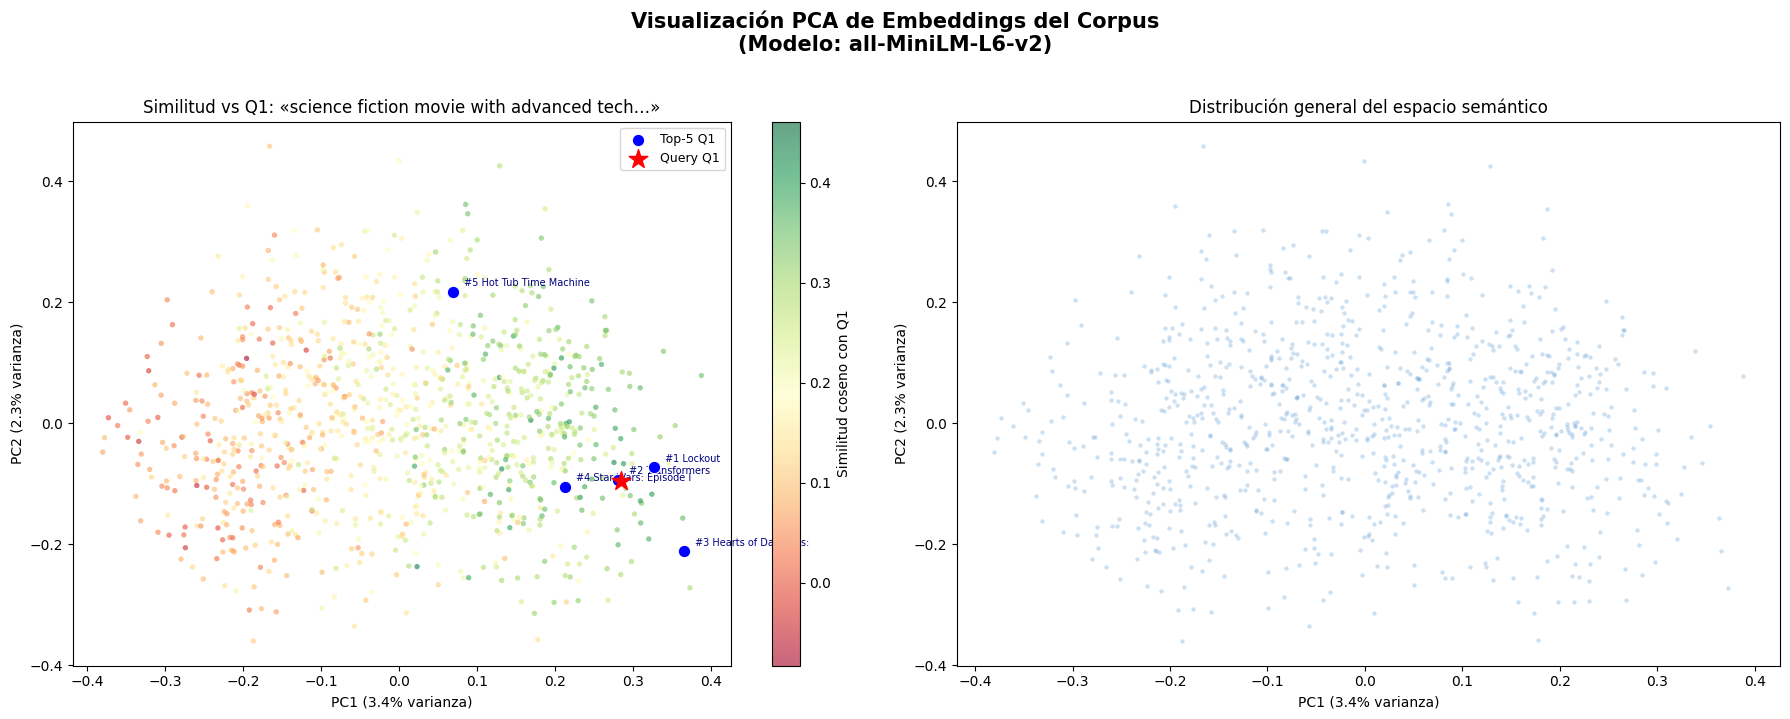


✅ Varianza explicada: PC1=3.4%  PC2=2.3%
   Total 2D explicado: 5.7%
💾 Gráfico guardado en 'pca_embeddings.png'


In [19]:
SAMPLE_VIZ = 1000
sample_idx = np.random.choice(len(df_corpus), size=min(SAMPLE_VIZ, len(df_corpus)), replace=False)
emb_sample = embeddings[sample_idx]
df_sample  = df_corpus.iloc[sample_idx].reset_index(drop=True)

# --- PCA a 2D ---
pca = PCA(n_components=2, random_state=RANDOM_SEED)
coords = pca.fit_transform(emb_sample)
var_explained = pca.explained_variance_ratio_

# Similitud de cada doc de la muestra contra Q1
q1_emb = model.encode(
    [preprocess_text(QUERIES["Q1"])],
    normalize_embeddings=True,
    convert_to_numpy=True
)
sims_q1 = cosine_similarity(q1_emb, emb_sample)[0]

# Top-5 en la muestra para Q1
top5_local = np.argsort(sims_q1)[::-1][:5]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("Visualización PCA de Embeddings del Corpus\n(Modelo: all-MiniLM-L6-v2)",
             fontsize=15, fontweight="bold", y=1.02)

# Subplot 1: similitud con Q1
ax1 = axes[0]
scatter = ax1.scatter(
    coords[:, 0], coords[:, 1],
    c=sims_q1, cmap="RdYlGn",
    alpha=0.6, s=15, linewidths=0
)

# Destacar top-5
ax1.scatter(
    coords[top5_local, 0], coords[top5_local, 1],
    c="blue", s=80, zorder=5, label="Top-5 Q1", edgecolors="white", linewidths=0.8
)

# Punto del query Q1 (CORREGIDO: Se usa "*" en lugar de "★" para evitar el ValueError)
q1_coords = pca.transform(q1_emb)
ax1.scatter(q1_coords[0, 0], q1_coords[0, 1],
            c="red", s=200, marker="*", zorder=6, label="Query Q1")

plt.colorbar(scatter, ax=ax1, label="Similitud coseno con Q1")
ax1.set_title(f"Similitud vs Q1: «{QUERIES['Q1'][:40]}…»")
ax1.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% varianza)")
ax1.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% varianza)")
ax1.legend(loc="upper right", fontsize=9)

# Subplot 2: densidad de puntos (distribución general)
ax2 = axes[1]
ax2.scatter(coords[:, 0], coords[:, 1], alpha=0.3, s=10, c="#5B9BD5", linewidths=0)
ax2.set_title("Distribución general del espacio semántico")
ax2.set_xlabel(f"PC1 ({var_explained[0]*100:.1f}% varianza)")
ax2.set_ylabel(f"PC2 ({var_explained[1]*100:.1f}% varianza)")

# Anotar los top-5 en el subplot 1
for i, idx in enumerate(top5_local):
    title_short = df_sample.iloc[idx]["movie_title"][:20]
    ax1.annotate(
        f"#{i+1} {title_short}",
        (coords[idx, 0], coords[idx, 1]),
        textcoords="offset points", xytext=(8, 4),
        fontsize=7, color="navy",
        arrowprops=dict(arrowstyle="-", color="gray", lw=0.5)
    )

plt.tight_layout()
plt.savefig("pca_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Varianza explicada: PC1={var_explained[0]*100:.1f}%  PC2={var_explained[1]*100:.1f}%")
print(f"   Total 2D explicado: {sum(var_explained)*100:.1f}%")
print("💾 Gráfico guardado en 'pca_embeddings.png'")

**Comparacion de los dos modelos de embeddings;**

Cargando Modelos...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Generando Embeddings...


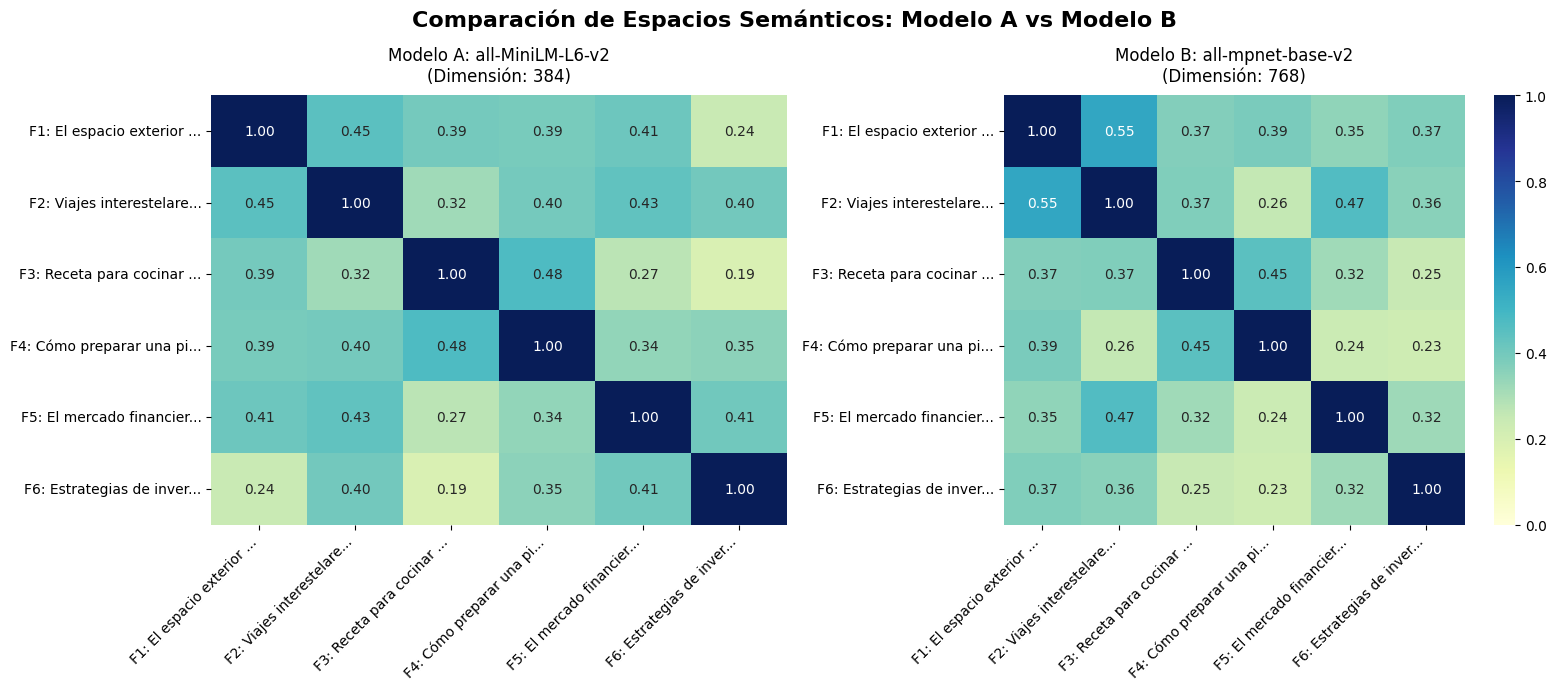

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Definir un set de frases de prueba con diferentes temáticas
# Esto nos permitirá ver si los modelos agrupan lo similar y separan lo distinto.
frases = [
    "El espacio exterior y las galaxias lejanas",        # Ciencia ficción / Astronomía
    "Viajes interestelares en naves espaciales",         # Ciencia ficción / Astronomía (Muy similar a 1)
    "Receta para cocinar una lasaña italiana",          # Cocina
    "Cómo preparar una pizza casera paso a paso",       # Cocina (Muy similar a 3)
    "El mercado financiero y las acciones de la bolsa",  # Economía
    "Estrategias de inversión y tasas de interés"       # Economía (Muy similar a 5)
]

# 2. Cargar los dos modelos que queremos comparar
print("Cargando Modelos...")
modelo_A = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')   # Ligero y rápido
modelo_B = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')  # Más pesado pero preciso

# 3. Generar los embeddings para cada modelo
print("Generando Embeddings...")
embeddings_A = modelo_A.encode(frases, normalize_embeddings=True)
embeddings_B = modelo_B.encode(frases, normalize_embeddings=True)

# 4. Calcular las matrices de similitud de coseno
similitud_A = cosine_similarity(embeddings_A)
similitud_B = cosine_similarity(embeddings_B)
# 5. Visualización mediante gráficos de calor (Heatmaps)
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Comparación de Espacios Semánticos: Modelo A vs Modelo B", fontsize=16, fontweight='bold')

# Etiquetas cortas para los ejes del gráfico
labels = [f"F{i+1}: {f[:20]}..." for i, f in enumerate(frases)]

# Heatmap Modelo A
sns.heatmap(
    similitud_A, xticklabels=labels, yticklabels=labels, 
    vmin=0, vmax=1, cmap="YlGnBu", annot=True, fmt=".2f", ax=axes[0], cbar=False
)
axes[0].set_title("Modelo A: all-MiniLM-L6-v2\n(Dimensión: 384)", fontsize=12, pad=10)
axes[0].set_xticklabels(labels, rotation=45, ha="right")

# Heatmap Modelo B (CORREGIDO: Se eliminó la comilla doble residual al final de la línea)
sns.heatmap(
    similitud_B, xticklabels=labels, yticklabels=labels, 
    vmin=0, vmax=1, cmap="YlGnBu", annot=True, fmt=".2f", ax=axes[1]
)
axes[1].set_title("Modelo B: all-mpnet-base-v2\n(Dimensión: 768)", fontsize=12, pad=10)
axes[1].set_xticklabels(labels, rotation=45, ha="right")

# Ajustes finales de diseño
plt.tight_layout()
plt.show()